In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df =pd.read_csv(r'D:\python2\netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [4]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
df[df['duration'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [6]:
mask = df['duration'].isna() & df['rating'].str.contains('min',na=False)
df.loc[mask, 'duration']=df.loc[mask,'rating']
df.loc[mask, 'rating']= 'NR'

In [7]:
df['director']=df['director'].fillna('unknown director')
df['cast']=df['cast'].fillna('unknown cast')
df['country']=df['country'].fillna('unknown country')
df['date_added']=df['date_added'].fillna('unknown date')
df['rating']=df['rating'].fillna('NR')
df['listed_in']=df['listed_in'].fillna('unknown listed_in')

In [8]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [9]:
movies_df = df.query("type == 'Movie'").copy()
movies_df['duration'] = movies_df['duration'].str.replace(' min', '', case=False)
movies_df['duration'] = pd.to_numeric(movies_df['duration'], errors='coerce').astype('Int64')
movies_df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown cast,United States,"September 25, 2021",2020,PG-13,90,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",unknown country,"September 24, 2021",2021,PG,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127,"Dramas, International Movies",After most of her family is murdered in a terr...
...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [10]:
shows_df = df.query("type == 'TV Show'").copy()

shows_df['duration'] = shows_df['duration'].str.replace(' Seasons', '', case=False).str.replace(' Season', '', case=False)
shows_df['duration'] = pd.to_numeric(shows_df['duration'], errors='coerce').astype('Int64')
shows_df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,unknown director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown country,"September 24, 2021",2021,TV-MA,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,unknown director,unknown cast,unknown country,"September 24, 2021",2021,TV-MA,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,unknown director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",unknown country,"September 24, 2021",2021,TV-MA,1,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
...,...,...,...,...,...,...,...,...,...,...,...,...
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,unknown director,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada","May 1, 2018",2015,TV-Y7,2,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...
8796,s8797,TV Show,Yunus Emre,unknown director,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,"January 17, 2017",2016,TV-PG,2,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8797,s8798,TV Show,Zak Storm,unknown director,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia","September 13, 2018",2016,TV-Y7,3,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8800,s8801,TV Show,Zindagi Gulzar Hai,unknown director,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."


In [11]:
movies_df['date_added']=pd.to_datetime(movies_df['date_added'])
shows_df['date_added']=pd.to_datetime(shows_df['date_added'],errors='coerce')
movies_df=movies_df.reset_index(drop=True)
shows_df=shows_df.reset_index(drop=True)

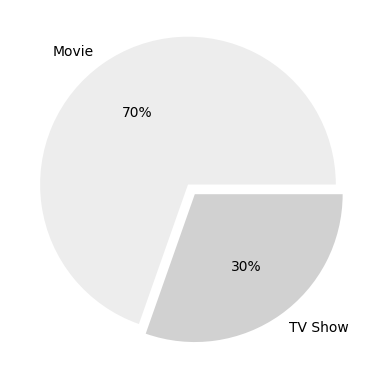

In [12]:
data = df.groupby("type")['type'].count()

explode=(0.08,0)
labels = ['Movie', 'TV Show']
colors = sns.color_palette("Greys")
plt.pie(data, labels=labels,colors = colors, autopct = '%0.0f%%', explode = explode)
plt.show()

In [13]:

movies_df['year']=movies_df['date_added'].dt.year
movies_df['month']=movies_df['date_added'].dt.month
shows_df['year']=shows_df['date_added'].dt.year
shows_df['month']=shows_df['date_added'].dt.month
shows_df['year']=pd.to_numeric(shows_df['year'],errors='coerce').astype('Int64')
shows_df['month']=pd.to_numeric(shows_df['month'],errors='coerce').astype('Int64')
movies_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year,month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown cast,United States,2021-09-25,2020,PG-13,90,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",unknown country,2021-09-24,2021,PG,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021,9
2,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021,9
3,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021,9
4,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127,"Dramas, International Movies",After most of her family is murdered in a terr...,2021,9


In [14]:
country_by_movies=movies_df['country'].str.split(', ').explode().str.strip()
top_10_country_by_movies=country_by_movies.value_counts()
top_10_country_by_movies=top_10_country_by_movies.reset_index(name='num_of_movies')
top_10_country_by_movies=top_10_country_by_movies.head(11)
top_10_country_by_movies=top_10_country_by_movies[top_10_country_by_movies['country']!= 'unknown country' ].reset_index(drop=True)
top_10_country_by_movies

,country,num_of_movies
0,United States,2751
1,India,962
2,United Kingdom,532
3,Canada,319
4,France,303
5,Germany,182
6,Spain,171
7,Japan,119
8,China,114
9,Mexico,111


In [15]:
country_by_shows=shows_df['country'].str.split(', ').explode()
top_10_country_by_shows=country_by_shows.value_counts()
top_10_country_by_shows=top_10_country_by_shows.reset_index(name='num_of_shows')
top_10_country_by_shows=top_10_country_by_shows.head(11)
top_10_country_by_shows=top_10_country_by_shows[top_10_country_by_shows['country']!= 'unknown country' ].reset_index(drop=True)
top_10_country_by_shows

,country,num_of_shows
0,United States,938
1,United Kingdom,272
2,Japan,199
3,South Korea,170
4,Canada,126
5,France,90
6,India,84
7,Taiwan,70
8,Australia,66
9,Spain,61


In [16]:
def clean_bar_axes( ):
	ax = plt.gca() 
	ax.invert_yaxis()
	ax.spines[['top','bottom','left','right']].set_visible(False)
	ax.grid(axis='x', color='black', alpha=0.5,linestyle='--')
	ax.tick_params(axis='both', length=0)

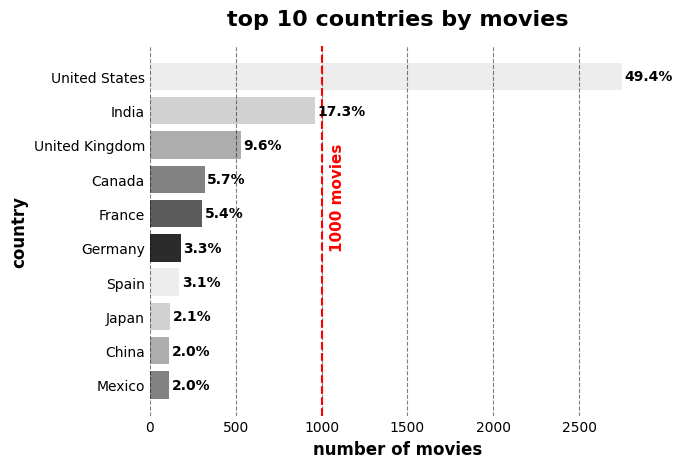

In [17]:
bars=plt.barh(top_10_country_by_movies['country'],top_10_country_by_movies['num_of_movies'],color= colors)
plt.title('top 10 countries by movies', fontsize=16, fontweight='bold',pad=15)
plt.xlabel('number of movies', fontsize=12, fontweight='bold')
plt.ylabel('country', fontsize=12, fontweight='bold')
clean_bar_axes()
plt.axvline(x=1000, color='red',linestyle='--', linewidth=1.5)
plt.text(1050,len('country')/2, '1000 movies',color='red', rotation=90,va='center', fontsize=11, fontweight='bold')
total_10_movies=top_10_country_by_movies['num_of_movies'].sum()
for bar in bars:
    width=bar.get_width()
    percentage= (width/total_10_movies)*100
    plt.text(width +15, bar.get_y() + bar.get_height()/2, f'{percentage:.1f}%',va='center',fontweight='bold',color= 'black')
plt.show()

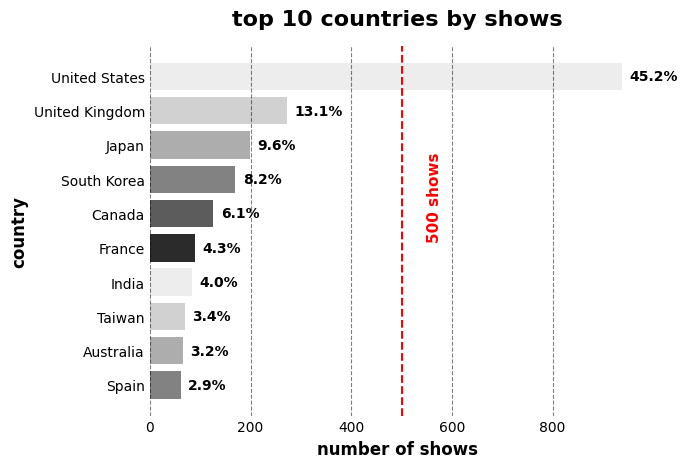

In [18]:

bars=plt.barh(top_10_country_by_shows['country'],top_10_country_by_shows['num_of_shows'],color= colors)
plt.title('top 10 countries by shows', fontsize=16, fontweight='bold',pad=15)
plt.xlabel('number of shows', fontsize=12, fontweight='bold')
plt.ylabel('country', fontsize=12, fontweight='bold')
clean_bar_axes()
plt.axvline(x=500, color='red',linestyle='--', linewidth=1.5)
plt.text(550,len('country')/2, '500 shows',color='red', rotation=90,va='center', fontsize=11, fontweight='bold')
total_10_shows=top_10_country_by_shows['num_of_shows'].sum()
for bar in bars:
    width=bar.get_width()
    percentage= (width/total_10_shows)*100
    plt.text(width +15, bar.get_y() + bar.get_height()/2, f'{percentage:.1f}%',va='center',fontweight='bold',color= 'black')
plt.show()

In [19]:
rate=df['rating'].value_counts()
rate=rate.reset_index(name='num_of_rate')
rate

,rating,num_of_rate
0,TV-MA,3207
1,TV-14,2160
2,TV-PG,863
3,R,799
4,PG-13,490
5,TV-Y7,334
6,TV-Y,307
7,PG,287
8,TV-G,220
9,NR,87


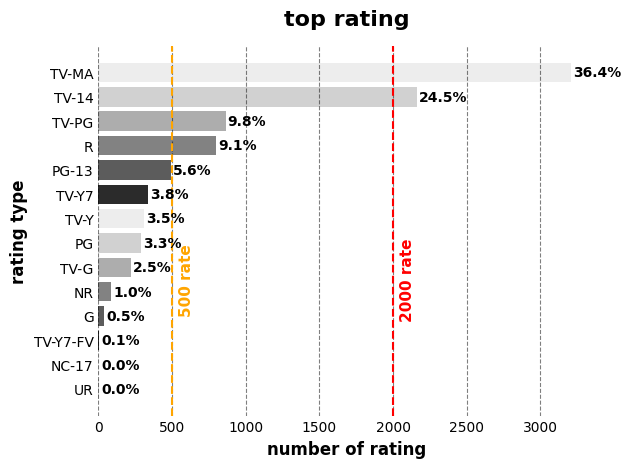

In [20]:
bars=plt.barh(rate['rating'],rate['num_of_rate'],color=colors)
plt.title('top rating', fontsize=16, fontweight='bold',pad=15)
plt.xlabel('number of rating', fontsize=12, fontweight='bold')
plt.ylabel('rating type', fontsize=12, fontweight='bold')
clean_bar_axes()
plt.axvline(x=2000, color='red',linestyle='--', linewidth=1.5)
plt.text(2050,len('rating')+2.5, '2000 rate',color='red', rotation=90,va='center', fontsize=11, fontweight='bold')
plt.axvline(x=500, color='orange',linestyle='--', linewidth=1.5)
plt.text(550,len('rating')+2.5, '500 rate',color='orange', rotation=90,va='center', fontsize=11, fontweight='bold')
total_rating=rate['num_of_rate'].sum()
for bar in bars:
    width=bar.get_width()
    percentage= (width/total_rating)*100
    plt.text(width +15, bar.get_y() + bar.get_height()/2, f'{percentage:.1f}%',va='center',fontweight='bold',color= 'black')
plt.show()


In [21]:
genres_exploded = df['listed_in'].str.split(', ').explode()
genres_df = genres_exploded.value_counts().reset_index()
genres_df.columns = ['genre_type', 'num_of_movies']
top_15_genres = genres_df.head(15)
top_15_genres

,genre_type,num_of_movies
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,763
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


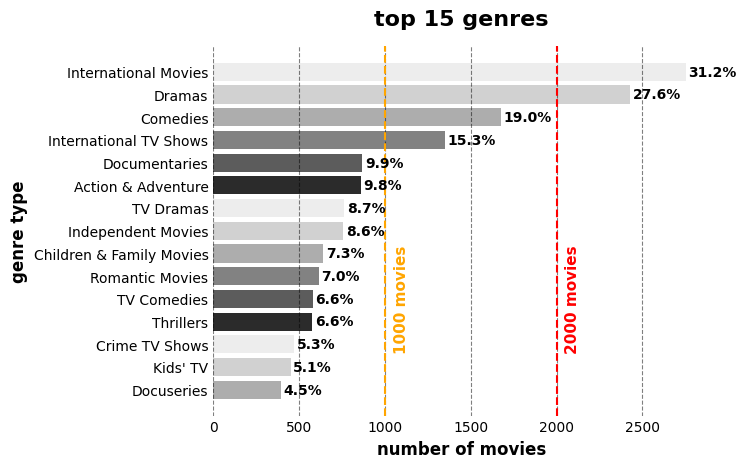

In [22]:
bars=plt.barh(top_15_genres['genre_type'],top_15_genres['num_of_movies'],color=colors)
plt.title('top 15 genres', fontsize=16, fontweight='bold',pad=15)
plt.xlabel('number of movies', fontsize=12, fontweight='bold')
plt.ylabel('genre type', fontsize=12, fontweight='bold')
clean_bar_axes()
plt.axvline(x=2000, color='red',linestyle='--', linewidth=1.5)
plt.text(2050,len('genre_type'), '2000 movies',color='red', rotation=90,va='center', fontsize=11, fontweight='bold')
plt.axvline(x=1000, color='orange',linestyle='--', linewidth=1.5)
plt.text(1050,len('genre_type'), '1000 movies',color='orange', rotation=90,va='center', fontsize=11, fontweight='bold')
total_rating=rate['num_of_rate'].sum()
for bar in bars:
    width=bar.get_width()
    percentage= (width/total_rating)*100
    plt.text(width +15, bar.get_y() + bar.get_height()/2, f'{percentage:.1f}%',va='center',fontweight='bold',color= 'black')
plt.show()

In [23]:
director = df['director'].str.split(', ').explode()
director = director.value_counts().reset_index()
director.columns = ['director', 'num_of_movies']
director=director.sort_values('num_of_movies',ascending=False)
director=director[director['director']!= 'unknown director']
director=director.head(10)
director.reset_index(drop=True)

,director,num_of_movies
0,Rajiv Chilaka,22
1,Jan Suter,21
2,Raúl Campos,19
3,Suhas Kadav,16
4,Marcus Raboy,16
5,Jay Karas,15
6,Cathy Garcia-Molina,13
7,Youssef Chahine,12
8,Martin Scorsese,12
9,Jay Chapman,12


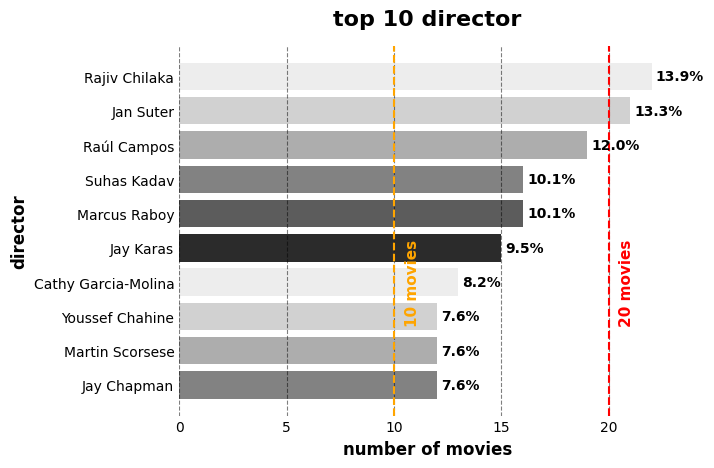

In [24]:
bars=plt.barh(director['director'],director['num_of_movies'],color=colors)
plt.title('top 10 director', fontsize=16, fontweight='bold',pad=15)
plt.xlabel('number of movies', fontsize=12, fontweight='bold')
plt.ylabel('director', fontsize=12, fontweight='bold')
clean_bar_axes()
plt.axvline(x=20, color='red',linestyle='--', linewidth=1.5)
plt.text(20.5,len('director')-2, '20 movies',color='red', rotation=90,va='center', fontsize=11, fontweight='bold')
plt.axvline(x=10, color='orange',linestyle='--', linewidth=1.5)
plt.text(10.5,len('director')-2, '10 movies',color='orange', rotation=90,va='center', fontsize=11, fontweight='bold')
director_top10=director['num_of_movies'].sum()
for bar in bars:
    width=bar.get_width()
    percentage= (width/director_top10)*100
    plt.text(width+0.2 , bar.get_y() + bar.get_height()/2, f'{percentage:.1f}%',va='center',fontweight='bold',color= 'black')
plt.show()

In [25]:
top_10_actor = df['cast'].str.split(', ').explode()
top_10_actor = top_10_actor.value_counts().reset_index()
top_10_actor.columns = ['actor', 'num_of_movies']
top_10_actor=top_10_actor.sort_values('num_of_movies',ascending=False)
top_10_actor=top_10_actor[top_10_actor['actor'] != 'unknown cast']
top_10_actor=top_10_actor.head(10)
top_10_actor.reset_index(drop=True)

,actor,num_of_movies
0,Anupam Kher,43
1,Shah Rukh Khan,35
2,Julie Tejwani,33
3,Naseeruddin Shah,32
4,Takahiro Sakurai,32
5,Rupa Bhimani,31
6,Akshay Kumar,30
7,Om Puri,30
8,Yuki Kaji,29
9,Amitabh Bachchan,28


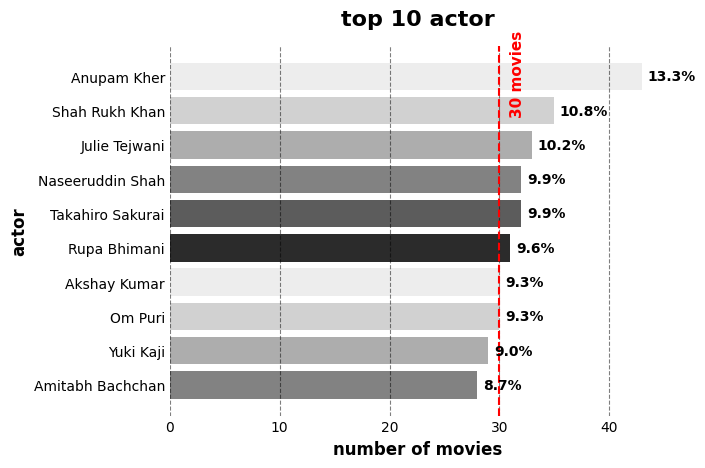

In [26]:
bars=plt.barh(top_10_actor['actor'],top_10_actor['num_of_movies'],color=colors)
plt.title('top 10 actor', fontsize=16, fontweight='bold',pad=15)
plt.xlabel('number of movies', fontsize=12, fontweight='bold')
plt.ylabel('actor', fontsize=12, fontweight='bold')
clean_bar_axes()
plt.axvline(x=30, color='red',linestyle='--', linewidth=1.5)
plt.text(31,-0.1, '30 movies',color='red', rotation=90,va='center', fontsize=11, fontweight='bold')
actor_top10=top_10_actor['num_of_movies'].sum()
for bar in bars:
    width=bar.get_width()
    percentage= (width/actor_top10)*100
    plt.text(width +0.5, bar.get_y() + bar.get_height()/2, f'{percentage:.1f}%',va='center',fontweight='bold',color= 'black')
plt.show()

In [27]:
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')
df['year']=df['date_added'].dt.year


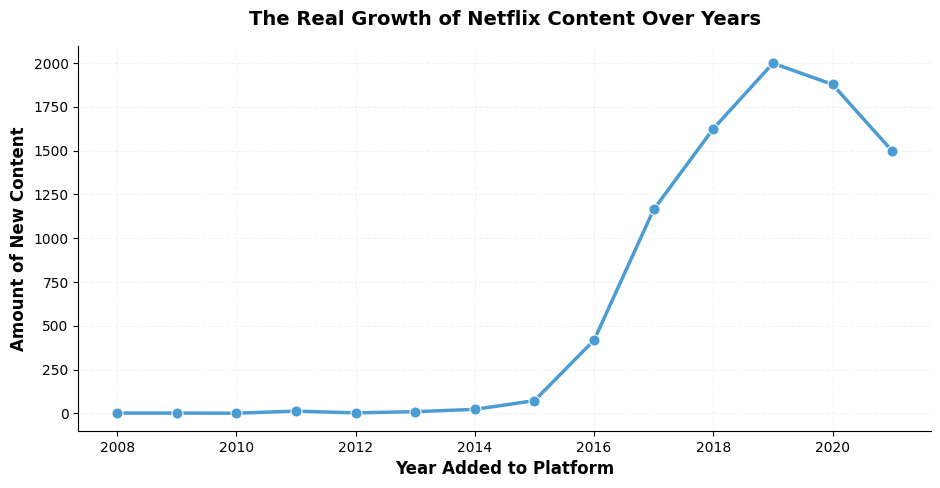

In [28]:
yearly_growth = df['year'].value_counts().sort_index().reset_index()
yearly_growth.columns = ['Year Added', 'Number of Content']
plt.figure(figsize=(11, 5))
sns.lineplot(
    data=yearly_growth, 
    x='Year Added', 
    y='Number of Content', 
    marker='o', 
    markersize=8,
    color='#4B9CD3',
    linewidth=2.5
)
plt.title('The Real Growth of Netflix Content Over Years', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year Added to Platform', fontsize=12, fontweight='bold')
plt.ylabel('Amount of New Content', fontsize=12, fontweight='bold')
plt.grid(axis='both', alpha=0.15, linestyle='--')
sns.despine()

plt.show()

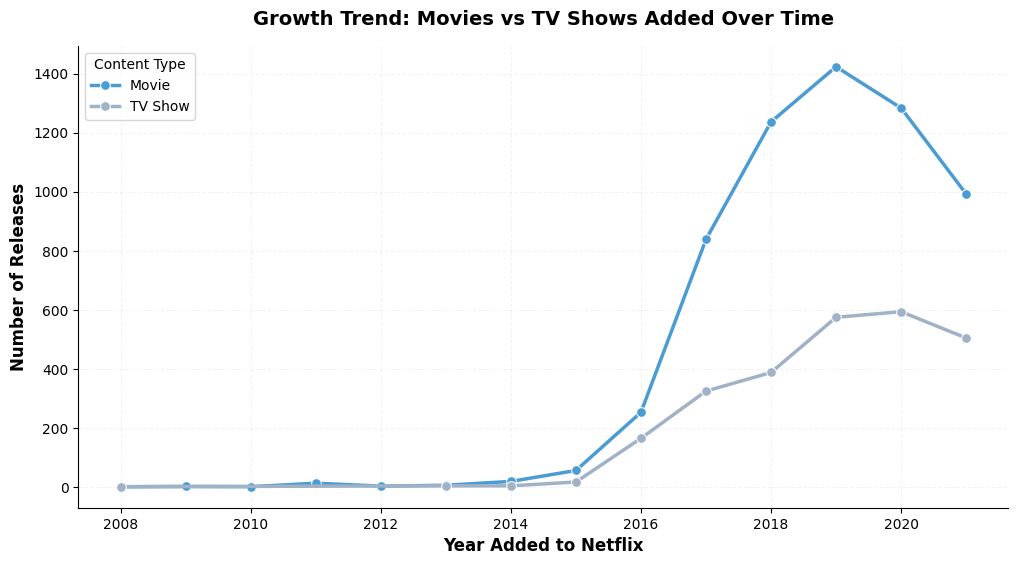

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
yearly_counts = df.groupby(['year', 'type']).size().reset_index(name='count')
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_counts, 
    x='year', 
    y='count', 
    hue='type', 
    marker='o', 
    markersize=7,
    linewidth=2.5,
    palette={'Movie': '#4B9CD3', 'TV Show': '#A0B2C6'}  
)

plt.title('Growth Trend: Movies vs TV Shows Added Over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year Added to Netflix', fontsize=12, fontweight='bold')
plt.ylabel('Number of Releases', fontsize=12, fontweight='bold')
plt.grid(axis='both', alpha=0.15, linestyle='--')
plt.legend(title='Content Type', frameon=True)
sns.despine()

plt.show()

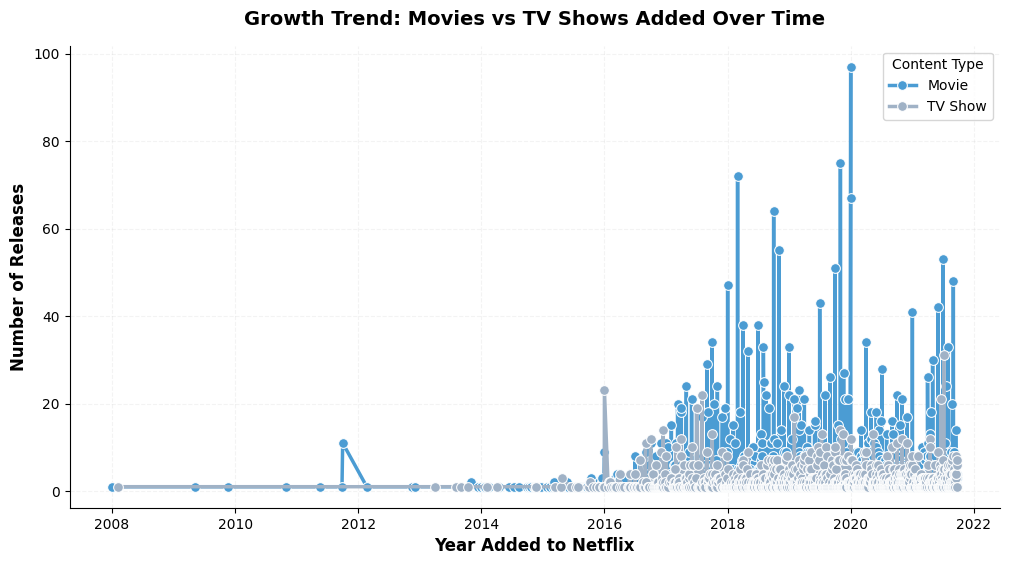

In [30]:

yearly_counts = df.groupby(['date_added', 'type']).size().reset_index(name='count')
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_counts, 
    x='date_added', 
    y='count', 
    hue='type', 
    marker='o', 
    markersize=7,
    linewidth=2.5,
    palette={'Movie': '#4B9CD3', 'TV Show': '#A0B2C6'}  
)

plt.title('Growth Trend: Movies vs TV Shows Added Over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year Added to Netflix', fontsize=12, fontweight='bold')
plt.ylabel('Number of Releases', fontsize=12, fontweight='bold')
plt.grid(axis='both', alpha=0.15, linestyle='--')
plt.legend(title='Content Type', frameon=True)
sns.despine()

plt.show()

In [31]:
country_movies_list=top_10_country_by_movies['country'].to_list()
country_shows_list=top_10_country_by_shows['country'].to_list()

countries_movies_dataframes={}
countries_shows_dataframes={}

def by_country(name,dataframe,my_dictionary,content_type):
    filtered_df=dataframe.query("country == @name")
    filtered_df=filtered_df.reset_index(drop=True)
    file_name = name.lower().replace(' ',('_'))
    my_dictionary[file_name]=filtered_df
    filtered_df.to_csv(f'{file_name}_{content_type}.csv',index=False)

for country in country_movies_list:
    by_country(country,movies_df,countries_movies_dataframes,'movies')

for country_key , df_value in countries_movies_dataframes.items():
    globals()[f"{country_key}_movies_df"]=df_value
for country in country_shows_list:
    by_country(country,shows_df,countries_shows_dataframes,'shows')

for country_key , df_value in countries_shows_dataframes.items():
    globals()[f"{country_key}_shows_df"]=df_value